In [2]:
import numpy as np
import pandas as pd
import os

class_path = []
file_path = []

for class_name in os.listdir(os.path.join("ISL_Dataset/custom_images")):
    for file_name in os.listdir(os.path.join("ISL_Dataset/custom_images", class_name)):
        file_path.append(os.path.join("ISL_Dataset", "custom_images", class_name, file_name))
        class_path.append(class_name)
df = pd.DataFrame(data={"class_path": class_path, "file_path": file_path})

In [3]:
df.head()

,class_path,file_path
0,0,ISL_Dataset\custom_images\0\0_0.jpg
1,0,ISL_Dataset\custom_images\0\0_1.jpg
2,0,ISL_Dataset\custom_images\0\0_10.jpg
3,0,ISL_Dataset\custom_images\0\0_100.jpg
4,0,ISL_Dataset\custom_images\0\0_1000.jpg


C:\Users\super\AppData\Local\Temp\ipykernel_13124\2684734047.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  seaborn.countplot(df['class_path'],palette="husl")


<Axes: title={'center': 'Class Distribution'}, xlabel='count', ylabel='class_path'>

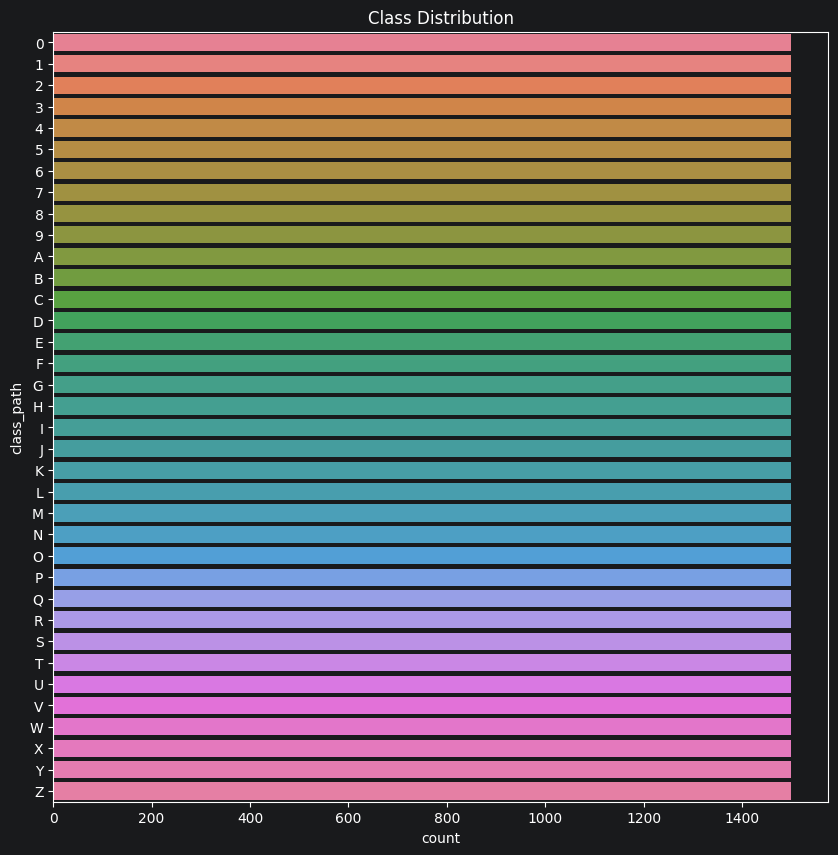

In [4]:
import matplotlib.pyplot as plt
import seaborn
plt.figure(figsize=(10,10))
plt.title("Class Distribution")
seaborn.countplot(df['class_path'],palette="husl")

In [5]:
df.to_csv("image_paths.csv", index=False, sep=",")

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

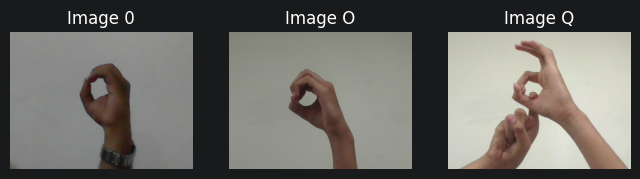

In [6]:
import cv2
import matplotlib.pyplot as plt

image_0 = cv2.imread("ISL_Dataset/custom_images/0/0_0.jpg")
image_O = cv2.imread("ISL_Dataset/custom_images/O/O_0.jpg")
image_Q = cv2.imread("ISL_Dataset/custom_images/Q/Q_0.jpg")

image_0 = cv2.cvtColor(image_0, cv2.COLOR_BGR2RGB)
image_O = cv2.cvtColor(image_O, cv2.COLOR_BGR2RGB)
image_Q = cv2.cvtColor(image_Q, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.imshow(image_0, cmap="gray")
plt.title("Image 0")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(image_O, cmap="gray")
plt.title("Image O")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(image_Q, cmap="gray")
plt.title("Image Q")
plt.axis("off")


(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

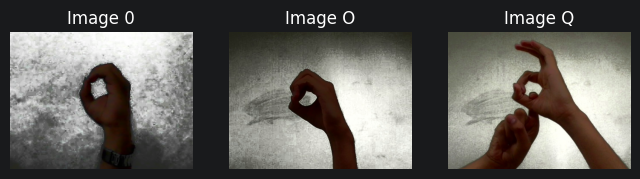

In [7]:
image_0_yuv = cv2.cvtColor(image_0, cv2.COLOR_BGR2YUV)
image_O_yuv = cv2.cvtColor(image_O, cv2.COLOR_BGR2YUV)
image_Q_yuv = cv2.cvtColor(image_Q, cv2.COLOR_BGR2YUV)

image_0_yuv[:,:,0] = cv2.equalizeHist(image_0_yuv[:,:,0])
image_O_yuv[:,:,0] = cv2.equalizeHist(image_O_yuv[:,:,0])
image_Q_yuv[:,:,0] = cv2.equalizeHist(image_Q_yuv[:,:,0])

image_0_enhanced = cv2.cvtColor(image_0_yuv, cv2.COLOR_YUV2BGR)
image_O_enhanced = cv2.cvtColor(image_O_yuv, cv2.COLOR_YUV2BGR)
image_Q_enhanced = cv2.cvtColor(image_Q_yuv, cv2.COLOR_YUV2BGR)

plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.imshow(image_0_enhanced, cmap="gray")
plt.title("Image 0")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(image_O_enhanced, cmap="gray")
plt.title("Image O")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(image_Q_enhanced, cmap="gray")
plt.title("Image Q")
plt.axis("off")

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

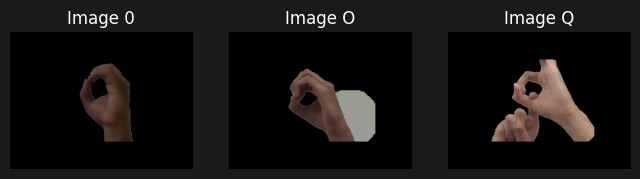

In [8]:

def remove_background(image, margin_pct=0.2):
    h, w = image.shape[:2]
    margin_x = int(margin_pct * w)
    margin_y = int(margin_pct * h)
    rect = (margin_x, margin_y, w - 2*margin_x, h - 2*margin_y)

    mask = np.zeros((h, w), np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)

    cv2.grabCut(image, mask, rect, bgdModel, fgdModel, 8, cv2.GC_INIT_WITH_RECT)

    # 0 and 2 = background, 1 and 3 = foreground -> collapse to binary 0/1
    binary_mask = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")

    result = image * binary_mask[:, :, np.newaxis]
    return result

image_0_nobg = remove_background(image_0)
image_O_nobg = remove_background(image_O)
image_Q_nobg = remove_background(image_Q)

plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.imshow(image_0_nobg)
plt.title("Image 0")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(image_O_nobg)
plt.title("Image O")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(image_Q_nobg)
plt.title("Image Q")
plt.axis("off")


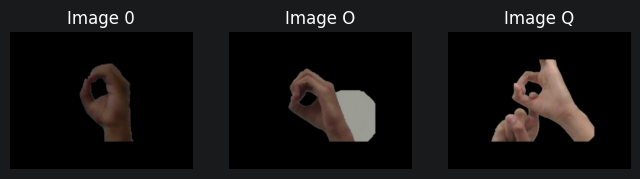

In [9]:
blurred_0 = cv2.GaussianBlur(image_0_nobg, (5,5), 0)
blurred_O = cv2.GaussianBlur(image_O_nobg, (5,5), 0)
blurred_Q = cv2.GaussianBlur(image_Q_nobg, (5,5), 0)

plt.figure(figsize=(8,4))
plt.subplot(1,3,1); plt.imshow(blurred_0); plt.title("Image 0"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(blurred_O); plt.title("Image O"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(blurred_Q); plt.title("Image Q"); plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

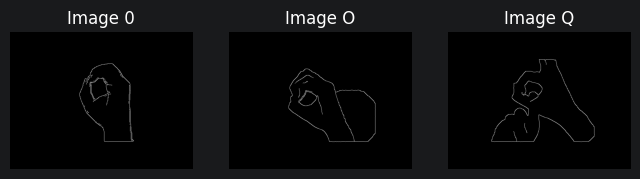

In [10]:
binary_mask_0 = np.any(image_0_nobg != 0, axis=2).astype("uint8")
binary_mask_O = np.any(image_O_nobg != 0, axis=2).astype("uint8")
binary_mask_Q = np.any(image_Q_nobg != 0, axis=2).astype("uint8")

foreground_pixels_0 = blurred_0[binary_mask_0 == 1]
foreground_pixels_O = blurred_O[binary_mask_O == 1]
foreground_pixels_Q = blurred_Q[binary_mask_Q == 1]

median_intensity_0 = np.median(foreground_pixels_0)
median_intensity_O = np.median(foreground_pixels_O)
median_intensity_Q = np.median(foreground_pixels_Q)

lower_threshold_0 = int(max(0, (1.0 - 0.33) * median_intensity_0))
upper_threshold_0 = int(min(255, (1.0 + 0.33) * median_intensity_0))
lower_threshold_O = int(max(0, (1.0 - 0.33) * median_intensity_O))
upper_threshold_O = int(min(255, (1.0 + 0.33) * median_intensity_O))
lower_threshold_Q = int(max(0, (1.0 - 0.33) * median_intensity_Q))
upper_threshold_Q = int(min(255, (1.0 + 0.33) * median_intensity_Q))

#Apply Canny
image_canny_0 = cv2.Canny(blurred_0, lower_threshold_0, upper_threshold_0)
image_canny_O = cv2.Canny(blurred_O, lower_threshold_O, upper_threshold_O)
image_canny_Q = cv2.Canny(blurred_Q, lower_threshold_Q, upper_threshold_Q)

plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.imshow(image_canny_0, cmap="gray")
plt.title("Image 0")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(image_canny_O, cmap="gray")
plt.title("Image O")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(image_canny_Q, cmap="gray")
plt.title("Image Q")
plt.axis("off")

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

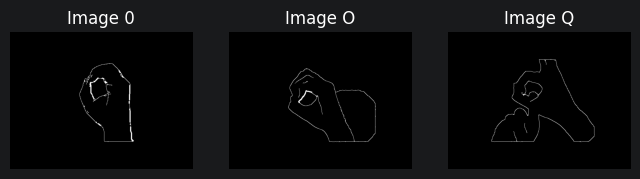

In [11]:
# Define a kernel (shape and size matter)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))

# Apply morphological operations on Canny edges
image_0_clean = cv2.morphologyEx(image_canny_0, cv2.MORPH_CLOSE, kernel)
image_O_clean = cv2.morphologyEx(image_canny_O, cv2.MORPH_CLOSE, kernel)
image_Q_clean = cv2.morphologyEx(image_canny_Q, cv2.MORPH_CLOSE, kernel)

# Optional: also try MORPH_OPEN to remove small specks
# image_0_clean = cv2.morphologyEx(image_canny_0, cv2.MORPH_OPEN, kernel)


plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.imshow(image_0_clean, cmap="gray")
plt.title("Image 0")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(image_O_clean, cmap="gray")
plt.title("Image O")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(image_Q_clean, cmap="gray")
plt.title("Image Q")
plt.axis("off")

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

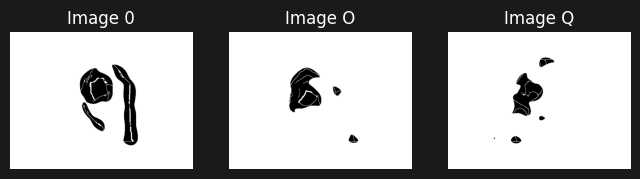

In [12]:
max_output_value = 255
neighbour_size = 99
subtract_from_mean = 10

image_0_binarized = cv2.adaptiveThreshold(image_0_clean, max_output_value, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, neighbour_size, subtract_from_mean)
image_O_binarized = cv2.adaptiveThreshold(image_O_clean, max_output_value, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, neighbour_size, subtract_from_mean)
image_Q_binarized = cv2.adaptiveThreshold(image_Q_clean, max_output_value, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, neighbour_size, subtract_from_mean)

plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.imshow(image_0_binarized, cmap="gray")
plt.title("Image 0")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(image_O_binarized, cmap="gray")
plt.title("Image O")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(image_Q_binarized, cmap="gray")
plt.title("Image Q")
plt.axis("off")

In [13]:
import urllib.request
url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
urllib.request.urlretrieve(url, "hand_landmarker.task")

('hand_landmarker.task', <http.client.HTTPMessage at 0x258a5cde2f0>)

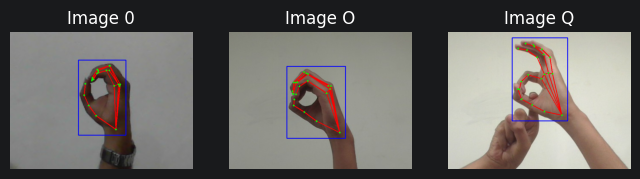

In [14]:
import mediapipe as mp

BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="hand_landmarker.task"),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=2
)
landmarker = HandLandmarker.create_from_options(options)

def detect_landmarks(image):
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image)
    result = landmarker.detect(mp_image)
    return result

HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),          # thumb
    (0,5),(5,6),(6,7),(7,8),          # index finger
    (0,9),(9,10),(10,11),(11,12),     # middle finger
    (0,13),(13,14),(14,15),(15,16),   # ring finger
    (0,17),(17,18),(18,19),(19,20),   # pinky
    (5,9),(9,13),(13,17)              # palm/knuckle connections
]

def draw_landmarks(image, result):
    h, w = image.shape[:2]
    annotated = image.copy()

    for hand_landmarks in result.hand_landmarks:
        xs = [lm.x * w for lm in hand_landmarks]
        ys = [lm.y * h for lm in hand_landmarks]
        x_min, x_max = int(min(xs)), int(max(xs))
        y_min, y_max = int(min(ys)), int(max(ys))

        padding = 20
        cv2.rectangle(
            annotated,
            (x_min - padding, y_min - padding),
            (x_max + padding, y_max + padding),
            (0, 0, 255), 2
        )

        for start_idx, end_idx in HAND_CONNECTIONS:
            start = hand_landmarks[start_idx]
            end = hand_landmarks[end_idx]
            x1, y1 = int(start.x * w), int(start.y * h)
            x2, y2 = int(end.x * w), int(end.y * h)
            cv2.line(annotated, (x1, y1), (x2, y2), (255, 0, 0), 2)

        for lm in hand_landmarks:
            x, y = int(lm.x * w), int(lm.y * h)
            cv2.circle(annotated, (x, y), 3, (0, 255, 0), -1)

    return annotated

result_0 = detect_landmarks(image_0)
result_O = detect_landmarks(image_O)
result_Q = detect_landmarks(image_Q)

annotated_0 = draw_landmarks(image_0, result_0)
annotated_O = draw_landmarks(image_O, result_O)
annotated_Q = draw_landmarks(image_Q, result_Q)

plt.figure(figsize=(8,4))
plt.subplot(1,3,1); plt.imshow(annotated_0); plt.title("Image 0"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(annotated_O); plt.title("Image O"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(annotated_Q); plt.title("Image Q"); plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

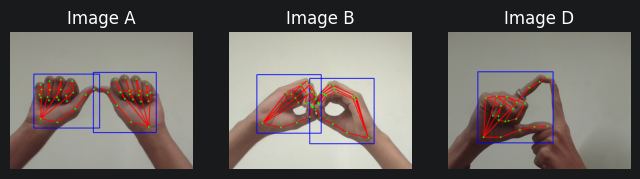

In [15]:
image_a = cv2.imread("ISL_Dataset/custom_images/A/A_0.jpg")
image_a = cv2.cvtColor(image_a, cv2.COLOR_BGR2RGB)
image_b = cv2.imread("ISL_Dataset/custom_images/B/B_0.jpg")
image_b = cv2.cvtColor(image_b, cv2.COLOR_BGR2RGB)
image_d = cv2.imread("ISL_Dataset/custom_images/D/D_0.jpg")
image_d = cv2.cvtColor(image_d, cv2.COLOR_BGR2RGB)

result_a = detect_landmarks(image_a)
annotated_a = draw_landmarks(image_a, result_a)

result_b = detect_landmarks(image_b)
annotated_b = draw_landmarks(image_b, result_b)

result_d = detect_landmarks(image_d)
annotated_d = draw_landmarks(image_d, result_d)

plt.figure(figsize=(8,4))
plt.subplot(1,3,1)
plt.imshow(annotated_a)
plt.title("Image A")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(annotated_b)
plt.title("Image B")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(annotated_d)
plt.title("Image D")
plt.axis("off")


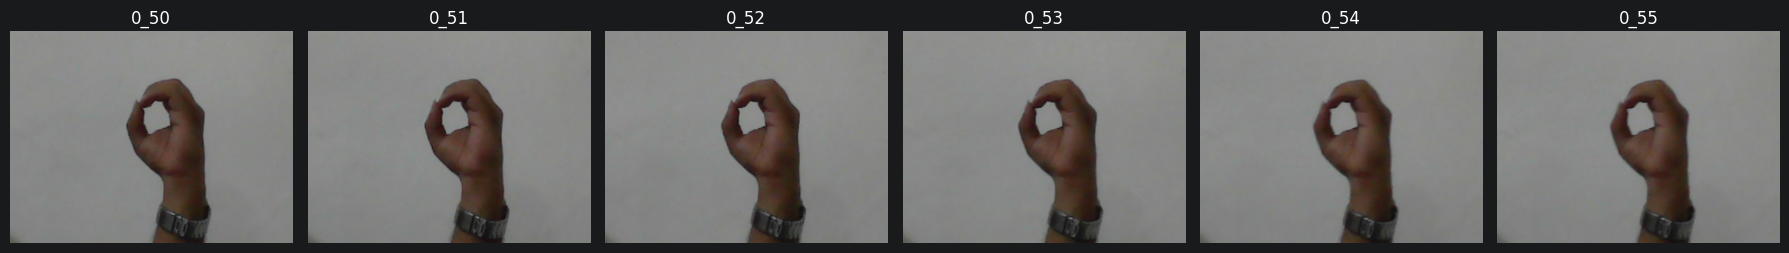

In [16]:
#

def load_rgb(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

class_name = "0"
start_idx = 50
num_images = 6

fig, axes = plt.subplots(1, num_images, figsize=(18, 3))

for i in range(num_images):
    idx = start_idx + i
    path = os.path.join("ISL_Dataset", "custom_images", class_name, f"{class_name}_{idx}.jpg")
    img = load_rgb(path)
    axes[i].imshow(img)
    axes[i].set_title(f"{class_name}_{idx}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [17]:
df['index'] = df['file_path'].str.split('_').str[-1].str.split('.').str[0].astype(int)
filtered_df = df[df['index'] % 5 == 0]
print(filtered_df)

      class_path                               file_path  index
0              0     ISL_Dataset\custom_images\0\0_0.jpg      0
2              0    ISL_Dataset\custom_images\0\0_10.jpg     10
3              0   ISL_Dataset\custom_images\0\0_100.jpg    100
4              0  ISL_Dataset\custom_images\0\0_1000.jpg   1000
9              0  ISL_Dataset\custom_images\0\0_1005.jpg   1005
...          ...                                     ...    ...
53973          Z   ISL_Dataset\custom_images\Z\Z_975.jpg    975
53979          Z   ISL_Dataset\custom_images\Z\Z_980.jpg    980
53984          Z   ISL_Dataset\custom_images\Z\Z_985.jpg    985
53990          Z   ISL_Dataset\custom_images\Z\Z_990.jpg    990
53995          Z   ISL_Dataset\custom_images\Z\Z_995.jpg    995

[10800 rows x 3 columns]


In [18]:
filtered_df['class_path'].value_counts()

class_path
0    300
1    300
2    300
3    300
4    300
5    300
6    300
7    300
8    300
9    300
A    300
B    300
C    300
D    300
E    300
F    300
G    300
H    300
I    300
J    300
K    300
L    300
M    300
N    300
O    300
P    300
Q    300
R    300
S    300
T    300
U    300
V    300
W    300
X    300
Y    300
Z    300
Name: count, dtype: int64

C:\Users\super\AppData\Local\Temp\ipykernel_13124\3450116346.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  seaborn.countplot(filtered_df['class_path'],palette="husl")


<Axes: title={'center': 'Class Distribution'}, xlabel='count', ylabel='class_path'>

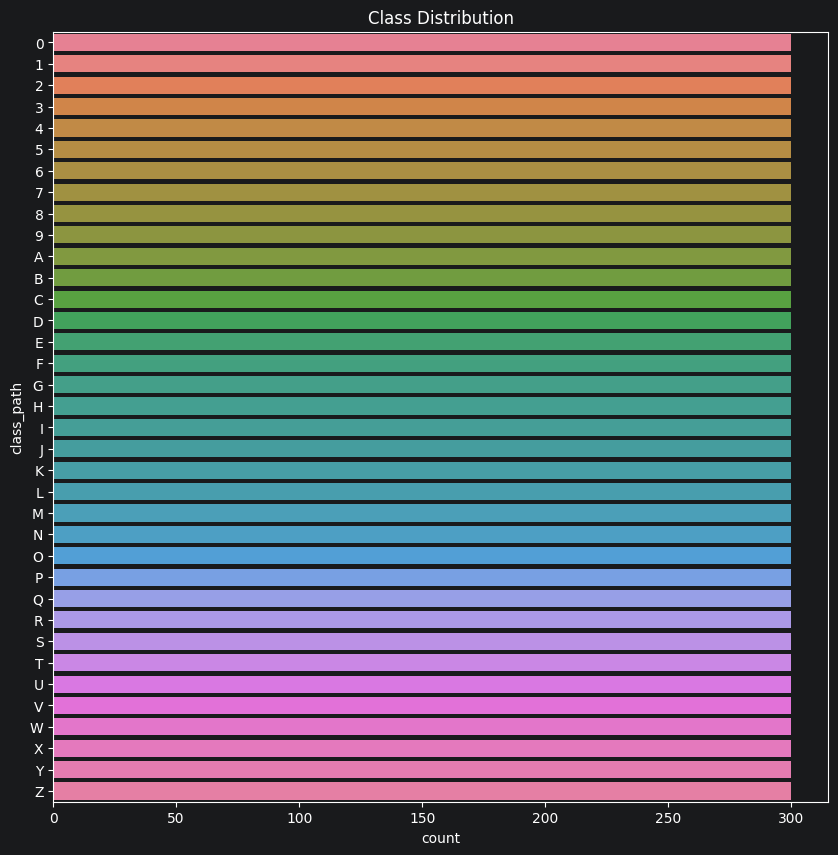

In [19]:
plt.figure(figsize=(10,10))
plt.title("Class Distribution")
seaborn.countplot(filtered_df['class_path'],palette="husl")

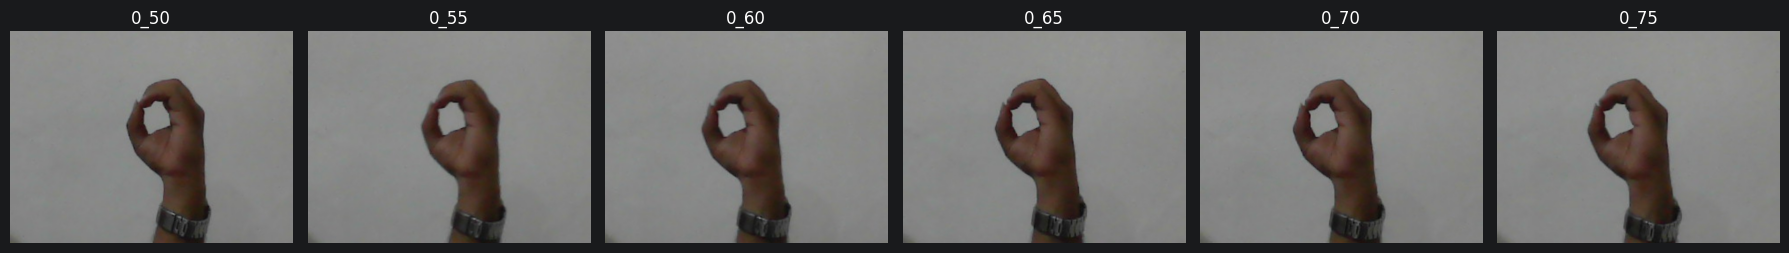

In [20]:
def load_rgb(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

class_name = "0"
start_idx = 50
step = 5
num_images = 6

fig, axes = plt.subplots(1, num_images, figsize=(18, 3))

for i in range(num_images):
    idx = start_idx + i * step
    match = filtered_df[(filtered_df['class_path'] == class_name) & (filtered_df['index'] == idx)]
    path = match['file_path'].iloc[0]
    img = load_rgb(path)
    axes[i].imshow(img)
    axes[i].set_title(f"{class_name}_{idx}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

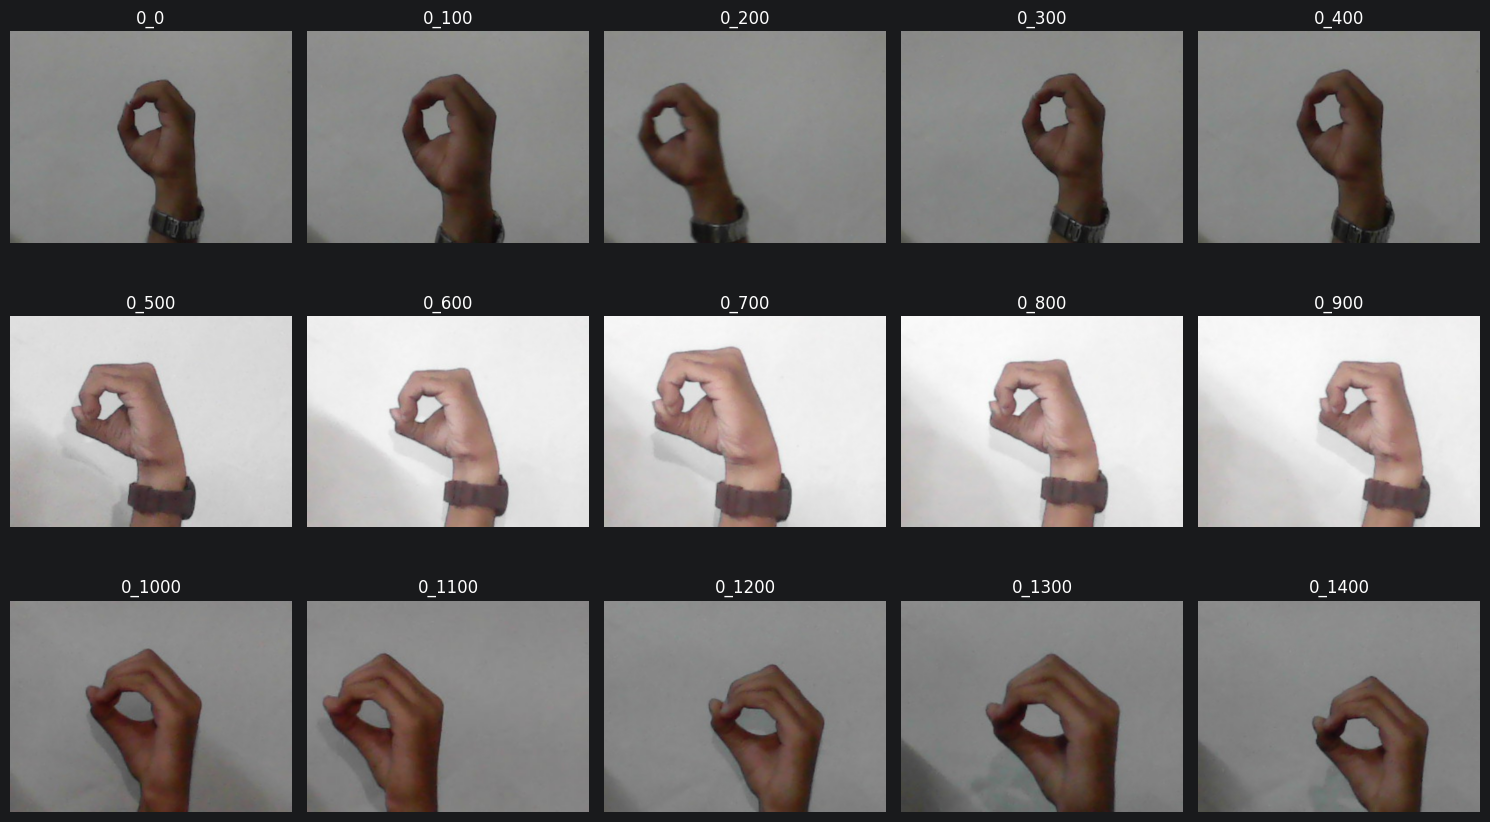

In [21]:
import matplotlib.pyplot as plt
import cv2

def load_rgb(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

class_name = "0"
start_idx = 0
step = 100
num_images = 15

# 3 rows, 5 columns ﷿﷿﷿ total 15 slots
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

# Flatten axes into a 1D list
axes = axes.flatten()

for i in range(num_images):
    idx = start_idx + i * step
    match = filtered_df[(filtered_df['class_path'] == class_name) & (filtered_df['index'] == idx)]
    if not match.empty:
        path = match['file_path'].iloc[0]
        img = load_rgb(path)
        axes[i].imshow(img)
        axes[i].set_title(f"{class_name}_{idx}")
        axes[i].axis("off")

plt.tight_layout()
plt.show()


In [22]:
from sklearn.model_selection import GroupShuffleSplit

# group_id: unique across classes too, so class 'A' group 3 isn't merged with class 'B' group 3
df['group_id'] = df['class_path'].astype(str) + "_" + (df['index'] // 100).astype(str)

X = df['file_path']
y = df['class_path']
groups = df['group_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(gss.split(X, y, groups=groups))

X_train, y_train, groups_train = X.iloc[train_idx], y.iloc[train_idx], groups.iloc[train_idx]
X_temp, y_temp, groups_temp = X.iloc[temp_idx], y.iloc[temp_idx], groups.iloc[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups=groups_temp))

X_val, y_val = X_temp.iloc[val_idx], y_temp.iloc[val_idx]
X_test, y_test = X_temp.iloc[test_idx], y_temp.iloc[test_idx]

print(X_train.shape, X_val.shape, X_test.shape)

(37800,) (8100,) (8100,)


In [23]:
df.head()

,class_path,file_path,index,group_id
0,0,ISL_Dataset\custom_images\0\0_0.jpg,0,0_0
1,0,ISL_Dataset\custom_images\0\0_1.jpg,1,0_0
2,0,ISL_Dataset\custom_images\0\0_10.jpg,10,0_0
3,0,ISL_Dataset\custom_images\0\0_100.jpg,100,0_1
4,0,ISL_Dataset\custom_images\0\0_1000.jpg,1000,0_10


In [24]:
print(y_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())

class_path
H    1300
7    1300
3    1200
E    1200
M    1200
S    1200
K    1200
J    1200
Y    1100
X    1100
T    1100
A    1100
F    1100
C    1100
V    1100
W    1100
Q    1100
6    1100
9    1100
8    1100
R    1100
U    1000
1    1000
2    1000
D    1000
B    1000
L    1000
P    1000
0     900
I     900
4     900
G     900
N     900
O     800
Z     800
5     600
Name: count, dtype: int64
class_path
Z    600
O    400
X    400
N    300
R    300
0    300
6    300
F    300
A    300
J    300
G    300
C    300
D    300
U    300
Q    300
B    300
1    200
2    200
4    200
P    200
V    200
7    200
K    200
9    200
H    200
5    100
8    100
I    100
3    100
L    100
M    100
S    100
T    100
W    100
Y    100
Name: count, dtype: int64
class_path
5    800
I    500
L    400
4    400
8    300
2    300
0    300
1    300
T    300
W    300
Y    300
P    300
N    300
O    300
E    300
G    300
V    200
U    200
M    200
S    200
B    200
9    200
3    200
D    200
F    100
C    100
A    1

In [25]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Get one split: this gives you train indices and "everything else" (temp) indices
train_idx, temp_idx = next(sgkf.split(X, y, groups=groups))

X_train, y_train, groups_train = X.iloc[train_idx], y.iloc[train_idx], groups.iloc[train_idx]
X_temp, y_temp, groups_temp = X.iloc[temp_idx], y.iloc[temp_idx], groups.iloc[temp_idx]

# Split temp into val/test, same approach
sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)
val_idx, test_idx = next(sgkf2.split(X_temp, y_temp, groups=groups_temp))

X_val, y_val = X_temp.iloc[val_idx], y_temp.iloc[val_idx]
X_test, y_test = X_temp.iloc[test_idx], y_temp.iloc[test_idx]

print(X_train.shape, X_val.shape, X_test.shape)

(43200,) (5500,) (5300,)


In [26]:
print(y_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())

class_path
2    1300
H    1300
J    1300
7    1300
T    1300
V    1300
R    1300
L    1300
Y    1200
Q    1200
1    1200
4    1200
F    1200
A    1200
C    1200
D    1200
8    1200
9    1200
5    1200
6    1200
Z    1200
W    1200
X    1200
E    1200
P    1200
O    1200
N    1200
K    1200
3    1100
0    1100
B    1100
G    1100
I    1100
M    1100
U    1100
S    1100
Name: count, dtype: int64
class_path
Y    300
Z    300
O    300
W    300
I    300
0    200
5    200
3    200
G    200
L    200
N    200
E    200
C    200
D    200
B    200
8    200
M    200
Q    200
9    100
1    100
2    100
4    100
6    100
7    100
F    100
A    100
H    100
R    100
U    100
T    100
S    100
X    100
Name: count, dtype: int64
class_path
S    300
U    300
K    300
P    300
0    200
1    200
3    200
B    200
J    200
F    200
M    200
6    200
4    200
9    200
A    200
X    200
V    200
G    200
C    100
8    100
5    100
2    100
7    100
E    100
D    100
H    100
I    100
N    100
Q    100
R    1

In [27]:

# --- Step 1: Diagnose group scarcity per class (with original 100-size groups) ---
df['group_id'] = df['class_path'].astype(str) + "_" + (df['index'] // 100).astype(str)
print("Groups per class (100-size):")
print(df.groupby('class_path')['group_id'].nunique().sort_values())
print()

# --- Step 2: Rebuild group_id with smaller groups for more flexibility ---
df['group_id'] = df['class_path'].astype(str) + "_" + (df['index'] // 50).astype(str)
print("Groups per class (50-size):")
print(df.groupby('class_path')['group_id'].nunique().sort_values())
print()

X = df['file_path']
y = df['class_path']
groups = df['group_id']

# --- Step 3: Split using StratifiedGroupKFold ---
sgkf = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=42)
train_idx, temp_idx = next(sgkf.split(X, y, groups=groups))

X_train, y_train, groups_train = X.iloc[train_idx], y.iloc[train_idx], groups.iloc[train_idx]
X_temp, y_temp, groups_temp = X.iloc[temp_idx], y.iloc[temp_idx], groups.iloc[temp_idx]

sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)
val_idx, test_idx = next(sgkf2.split(X_temp, y_temp, groups=groups_temp))

X_val, y_val = X_temp.iloc[val_idx], y_temp.iloc[val_idx]
X_test, y_test = X_temp.iloc[test_idx], y_temp.iloc[test_idx]

print(X_train.shape, X_val.shape, X_test.shape)
print()

# --- Step 4: Verify — every class must appear in every split ---
all_classes = set(df['class_path'].unique())

train_classes = set(y_train.unique())
val_classes = set(y_val.unique())
test_classes = set(y_test.unique())

print("Missing from train:", all_classes - train_classes)
print("Missing from val:  ", all_classes - val_classes)
print("Missing from test: ", all_classes - test_classes)
print()

print("train class counts:\n", y_train.value_counts())
print("\nval class counts:\n", y_val.value_counts())
print("\ntest class counts:\n", y_test.value_counts())

Groups per class (100-size):
class_path
0    15
1    15
2    15
3    15
4    15
5    15
6    15
7    15
8    15
9    15
A    15
B    15
C    15
D    15
E    15
F    15
G    15
H    15
I    15
J    15
K    15
L    15
M    15
N    15
O    15
P    15
Q    15
R    15
S    15
T    15
U    15
V    15
W    15
X    15
Y    15
Z    15
Name: group_id, dtype: int64

Groups per class (50-size):
class_path
0    30
1    30
2    30
3    30
4    30
5    30
6    30
7    30
8    30
9    30
A    30
B    30
C    30
D    30
E    30
F    30
G    30
H    30
I    30
J    30
K    30
L    30
M    30
N    30
O    30
P    30
Q    30
R    30
S    30
T    30
U    30
V    30
W    30
X    30
Y    30
Z    30
Name: group_id, dtype: int64

(45000,) (4450,) (4550,)

Missing from train: set()
Missing from val:   {'R'}
Missing from test:  set()

train class counts:
 class_path
2    1300
B    1300
7    1300
5    1300
U    1300
R    1300
X    1300
F    1300
H    1300
J    1300
N    1300
L    1300
W    1300
Z    1250
1    125

In [28]:

def try_split(seed):
    sgkf = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=seed)
    train_idx, temp_idx = next(sgkf.split(X, y, groups=groups))

    X_train, y_train, groups_train = X.iloc[train_idx], y.iloc[train_idx], groups.iloc[train_idx]
    X_temp, y_temp, groups_temp = X.iloc[temp_idx], y.iloc[temp_idx], groups.iloc[temp_idx]

    sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=seed)
    val_idx, test_idx = next(sgkf2.split(X_temp, y_temp, groups=groups_temp))

    X_val, y_val = X_temp.iloc[val_idx], y_temp.iloc[val_idx]
    X_test, y_test = X_temp.iloc[test_idx], y_temp.iloc[test_idx]

    all_classes = set(df['class_path'].unique())
    missing = (all_classes - set(y_train.unique())) | (all_classes - set(y_val.unique())) | (all_classes - set(y_test.unique()))

    return missing, (X_train, X_val, X_test, y_train, y_val, y_test)

for seed in range(50):
    missing, result = try_split(seed)
    if not missing:
        print(f"Found clean split at seed {seed}")
        X_train, X_val, X_test, y_train, y_val, y_test = result
        break
else:
    print("No seed in range found a fully clean split — consider shrinking group size further")

print(X_train.shape, X_val.shape, X_test.shape)

Found clean split at seed 0
(45000,) (4500,) (4500,)
